1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9046 - loss: 0.3026 - val_accuracy: 0.9868 - val_loss: 0.0446
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9831 - loss: 0.0538
Test accuracy: 0.9868000149726868
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


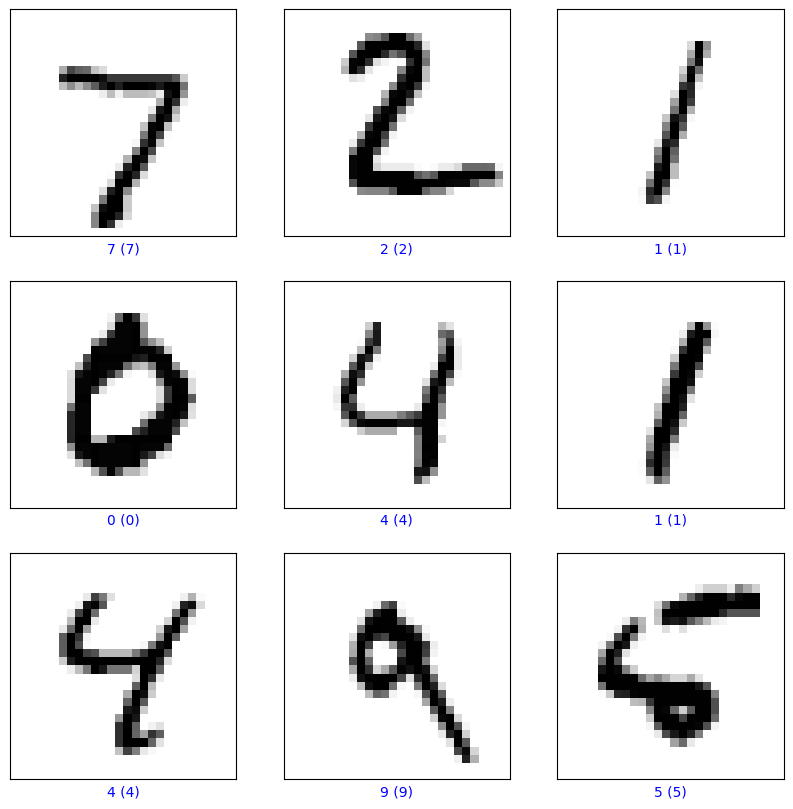

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1] range
x_train, x_test = x_train / 255.0, x_test / 255.0

# Reshape for CNN input (28x28x1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Define CNN model
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=1, validation_data=(x_test, y_test))

# Evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

# Make predictions
predictions = model.predict(x_test)

def plot_image(i, predictions_array, true_label, img):
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel(f"{predicted_label} ({true_label})", color=color)

# Display some predictions
num_rows, num_cols = 3, 3
plt.figure(figsize=(10, 10))
for i in range(num_rows * num_cols):
    plt.subplot(num_rows, num_cols, i+1)
    plot_image(i, predictions[i], y_test[i], x_test[i].reshape(28, 28))
plt.show()

# Function to predict multiple digits from an image
def predict_multiple_digits(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Load in grayscale
    _, img = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY_INV)  # Invert colors

    # Find contours
    contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Filter small contours
    valid_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > 100]

    digit_predictions = []

    for contour in valid_contours:
        x, y, w, h = cv2.boundingRect(contour)

        # Add padding to ensure square images
        padding = max(w, h)
        new_img = np.ones((padding, padding), dtype=np.uint8) * 0
        x_offset = (padding - w) // 2
        y_offset = (padding - h) // 2
        new_img[y_offset:y_offset+h, x_offset:x_offset+w] = img[y:y+h, x:x+w]

        # Resize to 28x28 for the model
        digit = cv2.resize(new_img, (28, 28))
        digit = digit / 255.0  # Normalize
        digit = digit.reshape(1, 28, 28, 1)  # Reshape for model input

        # Predict digit
        prediction = model.predict(digit)
        predicted_label = np.argmax(prediction)
        digit_predictions.append((x, predicted_label))  # Store with x-coordinate

    # Sort predictions by x-coordinate (left to right)
    digit_predictions.sort()

    predicted_numbers = [d[1] for d in digit_predictions]

    print("Predicted digits:", predicted_numbers)
    return predicted_numbers

# Example Usage: predict_multiple_digits("Test image.jpg")


In [5]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9831 - loss: 0.0538
Test Loss: 0.04459879919886589
Test Accuracy: 0.9868000149726868


In [9]:
predict_multiple_digits("/content/testimg3.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predicted digits: [1]


[1]